#  Red Wine EDA

In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score , precision_score , recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
# Data Load

df = pd.read_csv(r"../dataset/winequality-red.csv" , sep = ";")

df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
# Stats

print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

In [4]:
# Null Values

print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [5]:
# Duplicate

d = df.duplicated().sum()

p = ((d / df.shape[0]) * 100).round(2)

print(f"Count = {d} , Percent = {p} %")

Count = 240 , Percent = 15.01 %


# There are 15 % of rows which are duplicate

In [6]:
# Outlier

for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {(outliers / df.shape[0]) * 100}")

fixed acidity: 3.0644152595372107
volatile acidity: 1.188242651657286
citric acid: 0.06253908692933083
residual sugar: 9.693558474046279
chlorides: 7.004377736085053
free sulfur dioxide: 1.876172607879925
total sulfur dioxide: 3.4396497811131956
density: 2.8142589118198873
pH: 2.1888680425265794
sulphates: 3.6898061288305186
alcohol: 0.8130081300813009
quality: 1.7510944340212633


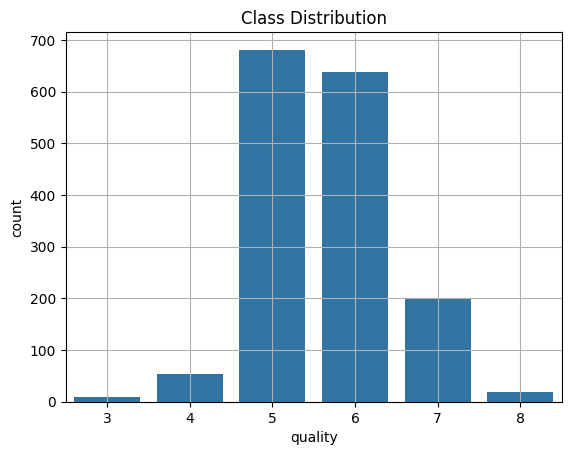

In [7]:
 # Class Distribution

sns.countplot(
    x = "quality" ,
    data = df
)

plt.title("Class Distribution")
plt.grid()
plt.show()

# Highly Imbalanced

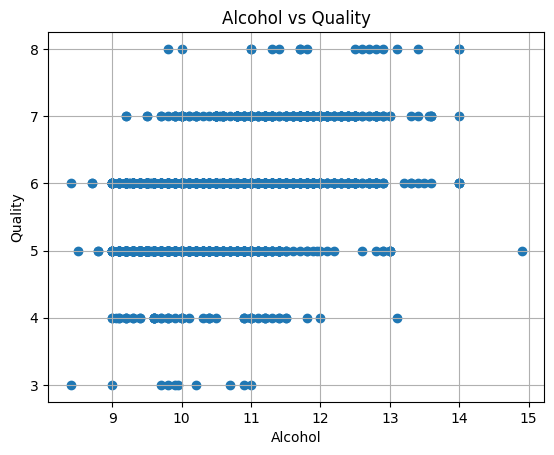

In [8]:
# Alcohol vs Quality

plt.scatter(
    x = df["alcohol"] ,
    y = df["quality"]
)
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Alcohol vs Quality")
plt.grid()
plt.show()

# There is no such direct relation between Alcohol and Quality

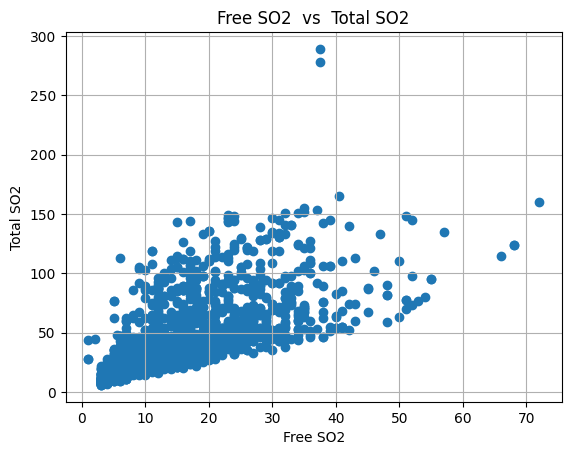

In [9]:
# Free SO2 vs Total SO2

plt.scatter(
    x = df["free sulfur dioxide"] ,
    y = df["total sulfur dioxide"]
)
plt.xlabel("Free SO2")
plt.ylabel("Total SO2")
plt.title("Free SO2  vs  Total SO2")
plt.grid()
plt.show()

# It is obvious that if free is increasing then total too

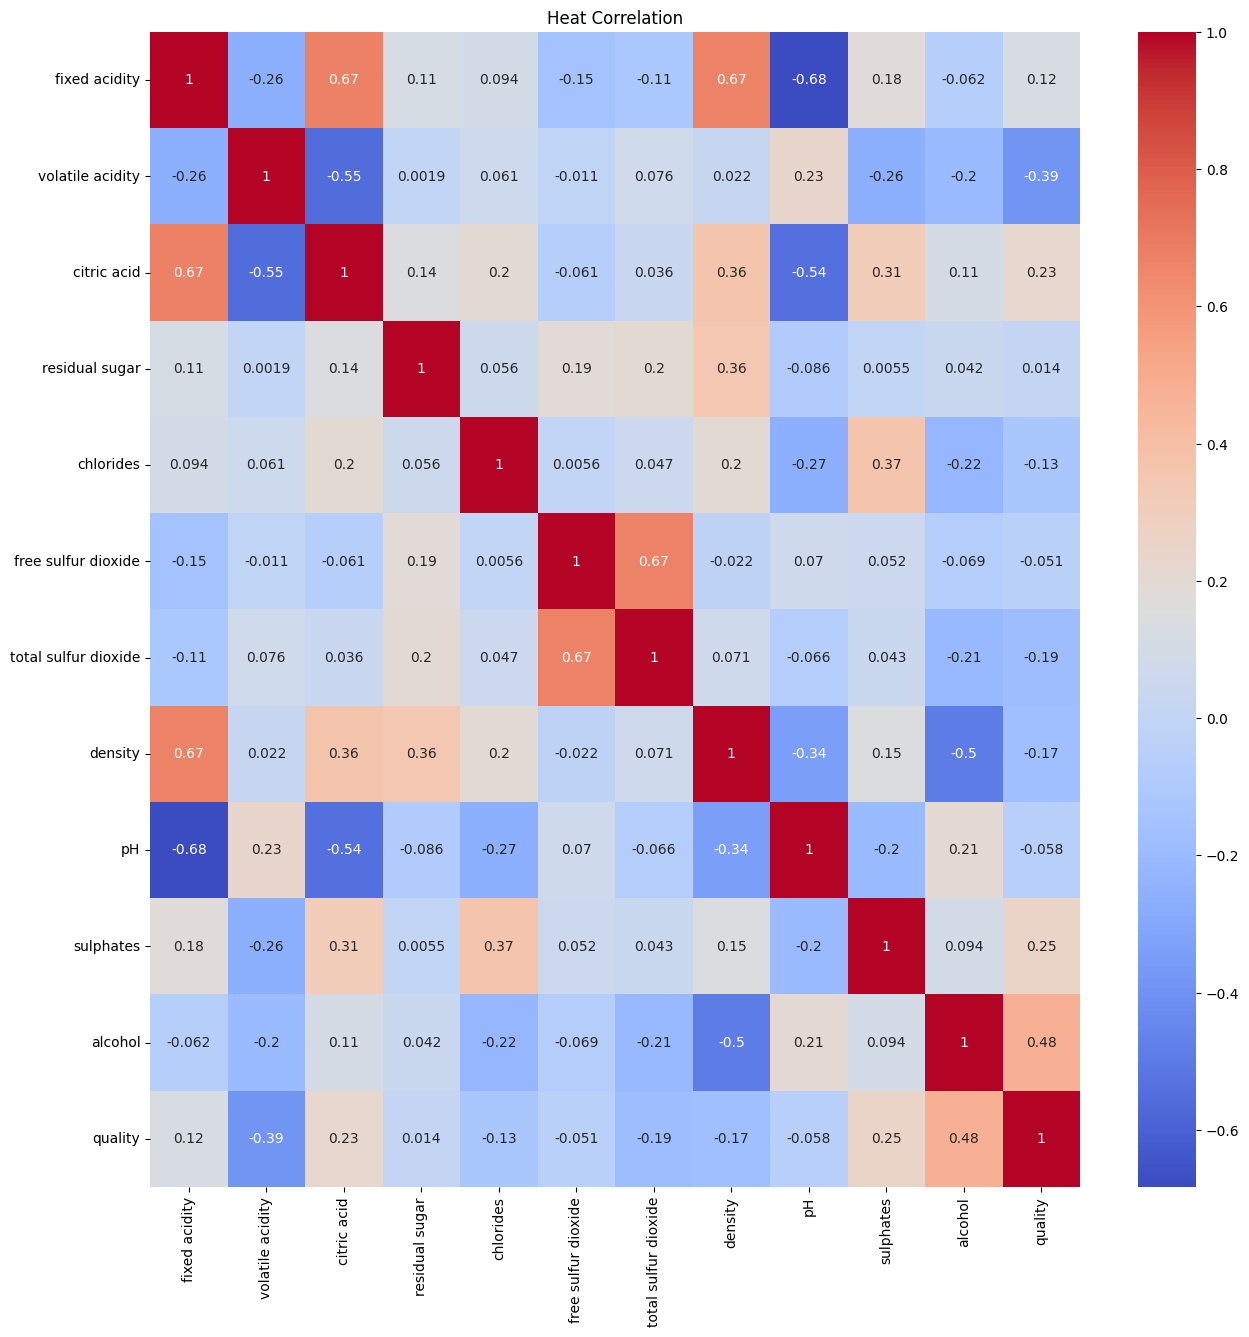

In [10]:
# Heat Map

plt.figure(figsize = (15 , 15))

sns.heatmap(
    df.corr(numeric_only = True) ,
    annot = True , 
    cmap = "coolwarm"
)

plt.title("Heat Correlation")
plt.show()

In [39]:
# Feature Importance (Base Model)

X = df.drop(["quality"] , axis = 1)
y = df["quality"]

X_train , X_test , y_train , y_test = train_test_split(
    X ,
    y ,
    test_size = 0.2 ,
    stratify = y ,
    random_state = 98
)

weight = compute_sample_weight(
    y = y_train ,
    class_weight = "balanced"
)

model = RandomForestClassifier()

model.fit(X_train , y_train , sample_weight = weight)

y_pred = model.predict(X_test)

imp = model.feature_importances_

imp = pd.Series(imp , index = X_train.columns).sort_values(ascending = False)
print("Important Feature :")
print(imp)

print()
print(f"F1 Score : {f1_score(y_test , y_pred , average = "weighted")}")
print(f"Precision : {precision_score(y_test , y_pred , average = "weighted")}")
print(f"Recall Score : {recall_score(y_test , y_pred , average = "weighted")}")

Important Feature :
volatile acidity        0.134978
alcohol                 0.128208
sulphates               0.108750
chlorides               0.101162
total sulfur dioxide    0.089018
density                 0.088053
citric acid             0.086664
fixed acidity           0.070714
pH                      0.070003
residual sugar          0.061561
free sulfur dioxide     0.060888
dtype: float64

F1 Score : 0.7045327154287918
Precision : 0.6892180700094608
Recall Score : 0.721875


C:\Users\sailj\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Class Weight is not necessarilt important here , as there is degrade in score

In [49]:
# Feature Importance (Base Model)

X = df.drop(["quality"] , axis = 1)
y = df["quality"]

X_train , X_test , y_train , y_test = train_test_split(
    X ,
    y ,
    test_size = 0.2 ,
    stratify = y ,
    random_state = 98
)

weight = compute_sample_weight(
    y = y_train ,
    class_weight = "balanced"
)

model = RandomForestClassifier()

model.fit(X_train , y_train )

y_pred = model.predict(X_test)

imp = model.feature_importances_

imp = pd.Series(imp , index = X_train.columns).sort_values(ascending = False)
print("Important Feature :")
print(imp)

print()
print(f"F1 Score : {f1_score(y_test , y_pred , average = "weighted")}")
print(f"Precision : {precision_score(y_test , y_pred , average = "weighted")}")
print(f"Recall Score : {recall_score(y_test , y_pred , average = "weighted")}")

Important Feature :
alcohol                 0.144520
sulphates               0.108045
total sulfur dioxide    0.105045
volatile acidity        0.102111
density                 0.093080
chlorides               0.081353
fixed acidity           0.078977
pH                      0.075437
residual sugar          0.072080
citric acid             0.072042
free sulfur dioxide     0.067309
dtype: float64

F1 Score : 0.7338612368024133
Precision : 0.7171052631578947
Recall Score : 0.753125


C:\Users\sailj\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# This warning shows that our model never predict few classes because dataset is higly imbalanced

# Volatile acidity is the most important feature in this dataset followed by alcohol while free SO2 is least imp